## **Executive Summary**

This project focuses on developing and evaluating machine learning models for credit card fraud detection, with a comparative analysis between the XGBoost, CatBoost and Random Forest classification algorithms. The objective is to identify the most effective model for accurately detecting fraudulent transactions while minimizing false positives, thereby improving the reliability and efficiency of fraud prevention systems in financial institutions.

The models were trained and optimized through hyperparameter tuning to enhance detection accuracy and computational efficiency. Among the models tested, CatBoost demonstrated the best overall performance, achieving the highest recall and slightly faster prediction time than XGBoost. This suggests that CatBoost was marginally more effective in identifying fraudulent transactions, which is critical in minimizing financial losses and false negatives. However, the improvement over XGBoost was modest.
XGBoost, on the other hand, exhibited significantly faster training time, making it a more computationally efficient choice for large-scale or frequently updated datasets. While its recall was marginally lower than CatBoost, its overall trade-off between speed and performance remains attractive for production environments where retraining speed is essential.
In contrast, Random Forest underperformed across all key metrics, showing lower recall and longer prediction times, making it less suitable for real-time fraud detection scenarios.

In summary, while both CatBoost and XGBoost performed strongly, CatBoost was the top performer in detection accuracy and prediction efficiency, whereas XGBoost remains the more practical choice for faster model updates. The results highlight that CatBoost may be preferred for accuracy-critical applications, while XGBoost may suit time-sensitive or resource-constrained systems. Future enhancements include integrating real-time detection pipelines, model retraining on new data, and exploring ensemble methods to combine the strengths of both models.

### **Import Libraries and Dataset**

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fraud-detection/fraudTest.csv
/kaggle/input/fraud-detection/fraudTrain.csv


In [2]:
test_data = '/kaggle/input/fraud-detection/fraudTest.csv'
train_data = '/kaggle/input/fraud-detection/fraudTrain.csv'

test_df = pd.read_csv(test_data,index_col=0)
train_df = pd.read_csv(train_data,index_col=0)

### **Exploratory Data Analysis**

We combine the two dataframes together such that it is easier to explore, clean up and make changes to the whole dataset.

This dataset is a simulated credit card transaction dataset containing legitimate and fraud transactions from the duration 1st Jan 2019 - 31st Dec 2020. It covers credit cards of 1000 customers doing transactions with a pool of 800 merchants.

The data consists of 22 columns, consisting of various information regarding the credit card owner and transaction details. The column 'is_fraud' indicates whether the transaction is legitimate or fraud, where 0 means it is legitimate and 1 indicates that it is a fraudulent transaction.

In [3]:
df = pd.concat([test_df, train_df])
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int64(5)

### **Feature Engineering**

To derive more meaningful insights from the date of birth of the credit card owners, we calculate their age.

In [5]:
import datetime as dt
df['age'] = dt.date.today().year-pd.to_datetime(df['dob']).dt.year

We also count the frequency of each credit card number, which allows us to have the frequency of transaction for each card. This may be useful for the model classification.

In [6]:
freq_enc = (df.groupby("cc_num").size())
df["cc_num_freq"] = df["cc_num"].apply(lambda x: freq_enc[x])

To derive more meaningful insights from the 'trans_date_trans_time' column, we separate the column into the hour of the day, day of the week and the month.

As the hour of the day, day of the week and month of the year are cyclical variables, we map each cyclical variable onto a circle such that the lowest value for that variable appears right next to the largest value. We compute the x- and y- component of that point using sin and cos trigonometric functions. 

In [7]:
df['hr'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
df['mnth'] = pd.to_datetime(df['trans_date_trans_time']).dt.month
df['week_day'] = pd.to_datetime(df['trans_date_trans_time']).dt.dayofweek

df['hr_sin'] = np.sin(df.hr*(2.*np.pi/24))
df['hr_cos'] = np.cos(df.hr*(2.*np.pi/24))
df['mnth_sin'] = np.sin((df.mnth-1)*(2.*np.pi/12))
df['mnth_cos'] = np.cos((df.mnth-1)*(2.*np.pi/12))
df['dayofweek_sin'] = np.sin((df.week_day)*(2.*np.pi/7))
df['dayofweek_cos'] = np.cos((df.week_day)*(2.*np.pi/7))

We will save a copy of the dataframe and drop columns that are not as useful or have similar purpose as other columns.

In [8]:
df_copy = df.copy(deep=True)

df.drop(columns=['first', 'last', 'street', 'trans_date_trans_time', 'dob', 'cc_num',
           'zip', 'hr', 'mnth', 'unix_time', 'trans_num', 'city_pop'], inplace=True)

We then convert the categorical variables to be 'category' as their data type, so as to allow our model to encode these categorical variables.

In [9]:
for feature in df.select_dtypes(include=['object']).columns:
    df[feature] = df[feature].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 1296674
Data columns (total 21 columns):
 #   Column         Dtype   
---  ------         -----   
 0   merchant       category
 1   category       category
 2   amt            float64 
 3   gender         category
 4   city           category
 5   state          category
 6   lat            float64 
 7   long           float64 
 8   job            category
 9   merch_lat      float64 
 10  merch_long     float64 
 11  is_fraud       int64   
 12  age            int64   
 13  cc_num_freq    int64   
 14  week_day       int32   
 15  hr_sin         float64 
 16  hr_cos         float64 
 17  mnth_sin       float64 
 18  mnth_cos       float64 
 19  dayofweek_sin  float64 
 20  dayofweek_cos  float64 
dtypes: category(6), float64(11), int32(1), int64(3)
memory usage: 235.0 MB


In [10]:
df.isnull().sum()

merchant         0
category         0
amt              0
gender           0
city             0
state            0
lat              0
long             0
job              0
merch_lat        0
merch_long       0
is_fraud         0
age              0
cc_num_freq      0
week_day         0
hr_sin           0
hr_cos           0
mnth_sin         0
mnth_cos         0
dayofweek_sin    0
dayofweek_cos    0
dtype: int64

In [11]:
duplicate = df[df.duplicated()]
print(duplicate)

Empty DataFrame
Columns: [merchant, category, amt, gender, city, state, lat, long, job, merch_lat, merch_long, is_fraud, age, cc_num_freq, week_day, hr_sin, hr_cos, mnth_sin, mnth_cos, dayofweek_sin, dayofweek_cos]
Index: []

[0 rows x 21 columns]


No cleaning was needed as the dataset had no missing, duplicate or null values.

In [12]:
counts = df["is_fraud"].value_counts()
print(counts)

is_fraud
0    1842743
1       9651
Name: count, dtype: int64


We can see that the total number of fraudulent cases make up only about 0.5% of the entire data, so the dataset is heavily imbalanced.

### **Declare Feature Vector and Target Variable**

In [13]:
X = df.drop('is_fraud', axis=1)

y = df['is_fraud']

### **Split Data Into Separate Training and Test Set**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 88)

## **XGBoostClassifier**

### **Hyperparameters Tuning**

In order to tune the hyperparameters, we employ the Bayesian optimization algorithm.

Traditional methods like grid search or random search explore hyperparameters blindly. Bayesian optimization, in contrast, builds a probabilistic model of the objective function and uses it to intelligently choose the next set of hyperparameters to evaluate. This means it focuses on the most promising regions of the search space, finding good results with fewer trials.

In [15]:
import optuna

def objective(trial):
    space = {'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'gamma': trial.suggest_float('gamma', 0, 10),
            'reg_alpha' : trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda' : trial.suggest_float('reg_lambda', 0, 10),
            'min_child_weight' : trial.suggest_int('min_child_weight', 0, 10),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
            }
    clf = xgb.XGBClassifier(**space, eval_metric = 'auc', early_stopping_rounds = 10, 
                            enable_categorical = True, random_state = 8)

    evaluation = [(X_test, y_test)]
    
    clf.fit(X_train, y_train,
            eval_set=evaluation,
            verbose=False)
    
    pred = clf.predict(X_test)
    score = accuracy_score(y_test, pred)
    return score

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=8))
study.optimize(objective, n_trials=20)

[I 2025-10-29 00:43:03,557] A new study created in memory with name: no-name-f73c441e-e680-4e4c-bfff-6338169c99db
[I 2025-10-29 00:43:14,069] Trial 0 finished with value: 0.9980421759918232 and parameters: {'learning_rate': 0.4368412719931163, 'max_depth': 10, 'gamma': 8.691945402139199, 'reg_alpha': 0.530855691555599, 'reg_lambda': 2.327283279772907, 'min_child_weight': 0, 'n_estimators': 487}. Best is trial 0 with value: 0.9980421759918232.
[I 2025-10-29 00:43:30,513] Trial 1 finished with value: 0.9985586240528037 and parameters: {'learning_rate': 0.20177332865864506, 'max_depth': 7, 'gamma': 4.783917958024024, 'reg_alpha': 0.5553564738223304, 'reg_lambda': 5.433860175425403, 'min_child_weight': 8, 'n_estimators': 741}. Best is trial 1 with value: 0.9985586240528037.
[I 2025-10-29 00:43:47,716] Trial 2 finished with value: 0.9986198060530592 and parameters: {'learning_rate': 0.3102213659556164, 'max_depth': 6, 'gamma': 2.8907502801808773, 'reg_alpha': 0.9738552412004462, 'reg_lambda

In [16]:
trial = study.best_trial
print('Accuracy: {}'.format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Accuracy: 0.9989257160543368
Best hyperparameters: {'learning_rate': 0.1530735143845312, 'max_depth': 10, 'gamma': 0.09938645870436505, 'reg_alpha': 0.4089641929934582, 'reg_lambda': 4.804929777791282, 'min_child_weight': 8, 'n_estimators': 845}


In [17]:
best_hyperparams_xgb = trial.params

### **Train the XGBoost Classifier**

In [18]:
import time

xgb_clf = xgb.XGBClassifier(**best_hyperparams_xgb, eval_metric = 'auc',
                            enable_categorical = True, random_state = 8)

start_train_time = time.perf_counter()
xgb_clf.fit(X_train, y_train)

end_train_time = time.perf_counter()
train_duration = end_train_time - start_train_time
print(f"Model training time: {train_duration:.4f} seconds")

Model training time: 60.2728 seconds


In [19]:
start_time_predict = time.perf_counter()
y_pred = xgb_clf.predict(X_test)
end_time_predict = time.perf_counter()
print(f"Model prediction time: {end_time_predict - start_time_predict:.4f} seconds")

Model prediction time: 4.3794 seconds


### **Evaluation of Model**

As the dataset is heavily imbalanced, it is not sufficient to just look at the accuracy. It is useful to evaluate the model using its precision and recall as well as the f1 score which is calculated based on the precision and recall.

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9989
Precision: 0.9500
Recall: 0.8443
F1 Score: 0.8940


### **Feature Importance**

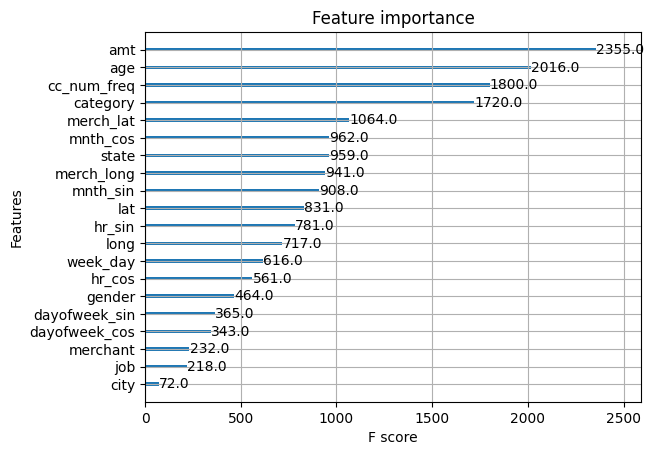

<Figure size 1600x1200 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_clf)
plt.figure(figsize = (16, 12))
plt.show()

Let's take a look at some of the important features in the prediction model as shown above. 

### **Transaction Amount**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

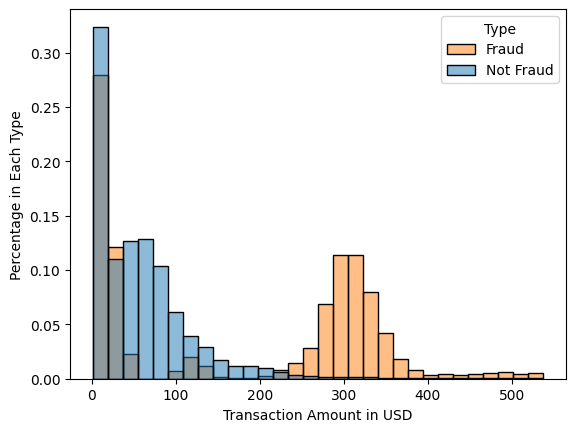

In [22]:
import seaborn as sns

p99 = df["amt"].quantile(0.99)
ax = sns.histplot(x = 'amt', data = df[df['amt'] <= p99],
                 hue = 'is_fraud', stat='probability',
                 common_norm = False, bins = 30)

ax.set_ylabel('Percentage in Each Type')
ax.set_xlabel('Transaction Amount in USD')
ax.legend(title='Type', labels=['Fraud', 'Not Fraud'])

We only take the 99th percentile of the transaction amounts so as to prevent abnormally large amount from skewing the distribution. Looking at the histogram plot above, we can see that the transaction amount for fraudulent transactions tend to be larger.

### **Age of Customers**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

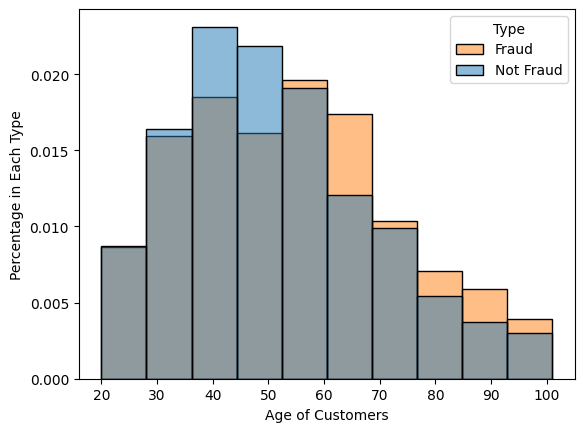

In [23]:
ax = sns.histplot(x = 'age', data = df,
                 hue = 'is_fraud', stat='density',
                 common_norm = False, bins = 10)

ax.set_ylabel('Percentage in Each Type')
ax.set_xlabel('Age of Customers')
ax.legend(title='Type', labels=['Fraud', 'Not Fraud'])

It seems that customers in the older age groups ranging from mid 50s onwards are more susceptible to credit card frauds. 

### **Transaction Category**

In [24]:
non_fraud = df[df['is_fraud'] == 0]['category'].value_counts(
    normalize=True).to_frame().reset_index()
non_fraud.columns = ['category', 'not_fraud_pct']

fraud = df[df['is_fraud'] == 1]['category'].value_counts(
    normalize=True).to_frame().reset_index()
fraud.columns = ['category', 'fraud_pct']

df_cat = non_fraud.merge(fraud, on='category')
df_cat['fraud_lvl'] = df_cat['fraud_pct'] - df_cat['not_fraud_pct']
print(df_cat)

          category  not_fraud_pct  fraud_pct  fraud_lvl
0    gas_transport       0.101619   0.079992  -0.021627
1             home       0.095073   0.027458  -0.067615
2      grocery_pos       0.094404   0.230857   0.136453
3     shopping_pos       0.089761   0.109419   0.019657
4        kids_pets       0.087599   0.031499  -0.056100
5     shopping_net       0.074402   0.229924   0.155523
6    entertainment       0.072623   0.030256  -0.042367
7      food_dining       0.070831   0.021241  -0.049590
8    personal_care       0.070436   0.030049  -0.040387
9   health_fitness       0.066405   0.019169  -0.047236
10        misc_pos       0.061814   0.033364  -0.028449
11        misc_net       0.048554   0.122474   0.073921
12     grocery_net       0.035112   0.018133  -0.016979
13          travel       0.031366   0.016164  -0.015202


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


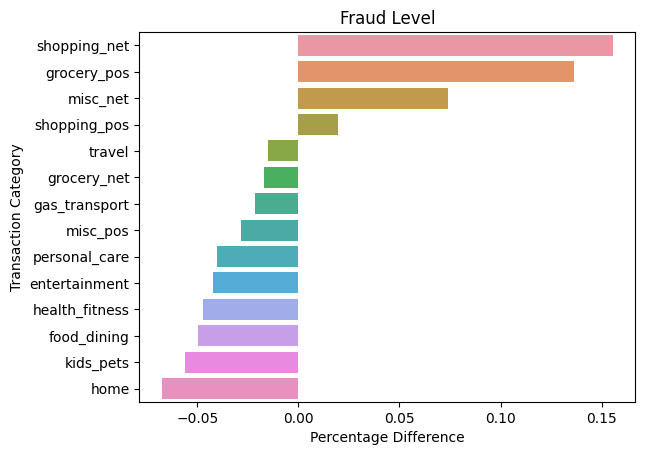

In [25]:
ax = sns.barplot(y='category', x='fraud_lvl',
                 data=df_cat, order=df_cat.sort_values('fraud_lvl', ascending=False).category)
ax.set_xlabel('Percentage Difference')
ax.set_ylabel('Transaction Category')
plt.title('Fraud Level');

We can see from the bar plot above that certain categories such as shopping and groceries are more prone to fraudulent transactions.

### **Credit Card Usage Frequency**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


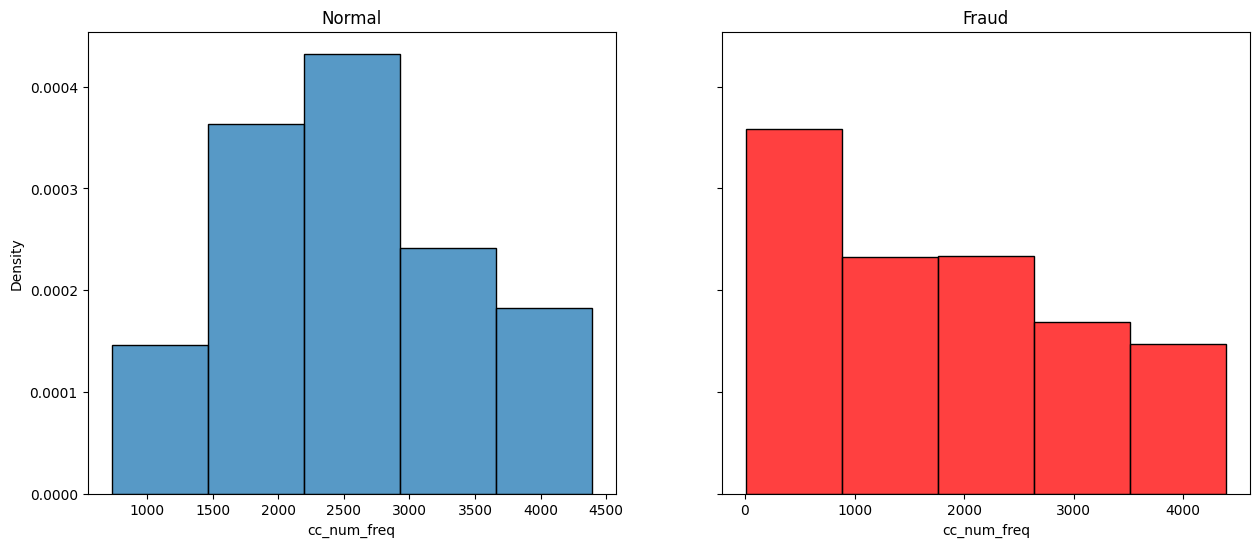

In [26]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
ax1 = sns.histplot(x='cc_num_freq', data=df[df["is_fraud"] == 0],
                   stat="density", bins=5, ax=ax1)
ax2 = sns.histplot(x='cc_num_freq', data=df[df["is_fraud"] == 1],
                   stat="density", bins=5, ax=ax2, color="red")
ax1.set_title("Normal")
ax2.set_title("Fraud");

We can see from the histogram above that credit cards that have lesser transactions have a higher probability of fraudulent transactions. 

## **CatBoostClassifier**

In [27]:
from catboost import CatBoostClassifier

In [28]:
import optuna

def objective(trial):
    space = {'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg' : trial.suggest_float('l2_leaf_reg', 0, 10),
            'iterations': trial.suggest_int('iterations', 100, 1000)
            }
    cb = CatBoostClassifier(**space, eval_metric = 'AUC', early_stopping_rounds = 10, 
                            random_state = 8, cat_features=['merchant', 'category', 'gender',
                                                            'city', 'state', 'job'])

    evaluation = [(X_test, y_test)]
    
    cb.fit(X_train, y_train,
            eval_set=evaluation,
            verbose=False)

    pred = cb.predict(X_test)
    score = accuracy_score(y_test, pred)
    return score

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=8))
study.optimize(objective, n_trials=20)   

[I 2025-10-29 00:54:49,239] A new study created in memory with name: no-name-c30ddc97-c721-4c92-a2ab-4a5a049a2060
[I 2025-10-29 00:59:18,771] Trial 0 finished with value: 0.9990030932899541 and parameters: {'learning_rate': 0.4368412719931163, 'depth': 10, 'l2_leaf_reg': 8.691945402139199, 'iterations': 578}. Best is trial 0 with value: 0.9990030932899541.
[I 2025-10-29 01:04:04,801] Trial 1 finished with value: 0.9985892150529314 and parameters: {'learning_rate': 0.11713143566066807, 'depth': 3, 'l2_leaf_reg': 4.304688182924905, 'iterations': 462}. Best is trial 0 with value: 0.9990030932899541.
[I 2025-10-29 01:08:55,090] Trial 2 finished with value: 0.9989868980545923 and parameters: {'learning_rate': 0.2618146610049322, 'depth': 6, 'l2_leaf_reg': 5.553564738223304, 'iterations': 589}. Best is trial 0 with value: 0.9990030932899541.
[I 2025-10-29 01:11:19,171] Trial 3 finished with value: 0.9989221171131453 and parameters: {'learning_rate': 0.38068689222586155, 'depth': 8, 'l2_leaf_

In [29]:
trial = study.best_trial
print('Accuracy: {}'.format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Accuracy: 0.9990498795254437
Best hyperparameters: {'learning_rate': 0.2853258503264593, 'depth': 7, 'l2_leaf_reg': 6.787800784250247, 'iterations': 266}


In [30]:
best_hyperparams_cb = trial.params

In [31]:
cb = CatBoostClassifier(**best_hyperparams_cb, eval_metric = 'AUC', early_stopping_rounds = 10, 
                            random_state = 8, cat_features=['merchant', 'category', 'gender',
                                                            'city', 'state', 'job'])

start_train_time = time.perf_counter()

cb.fit(X_train, y_train, eval_set=(X_test, y_test), silent=True)

end_train_time = time.perf_counter()
train_duration = end_train_time - start_train_time
print(f"Model training time: {train_duration:.4f} seconds")

Model training time: 306.4453 seconds


In [32]:
start_time_predict = time.perf_counter()
y_pred = cb.predict(X_test)
end_time_predict = time.perf_counter()
print(f"Model prediction time: {end_time_predict - start_time_predict:.4f} seconds")

Model prediction time: 2.2895 seconds


In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9990
Precision: 0.9706
Recall: 0.8453
F1 Score: 0.9036


### **Feature Importance**

/tmp/ipykernel_36/2039084756.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(feature_scores.index)


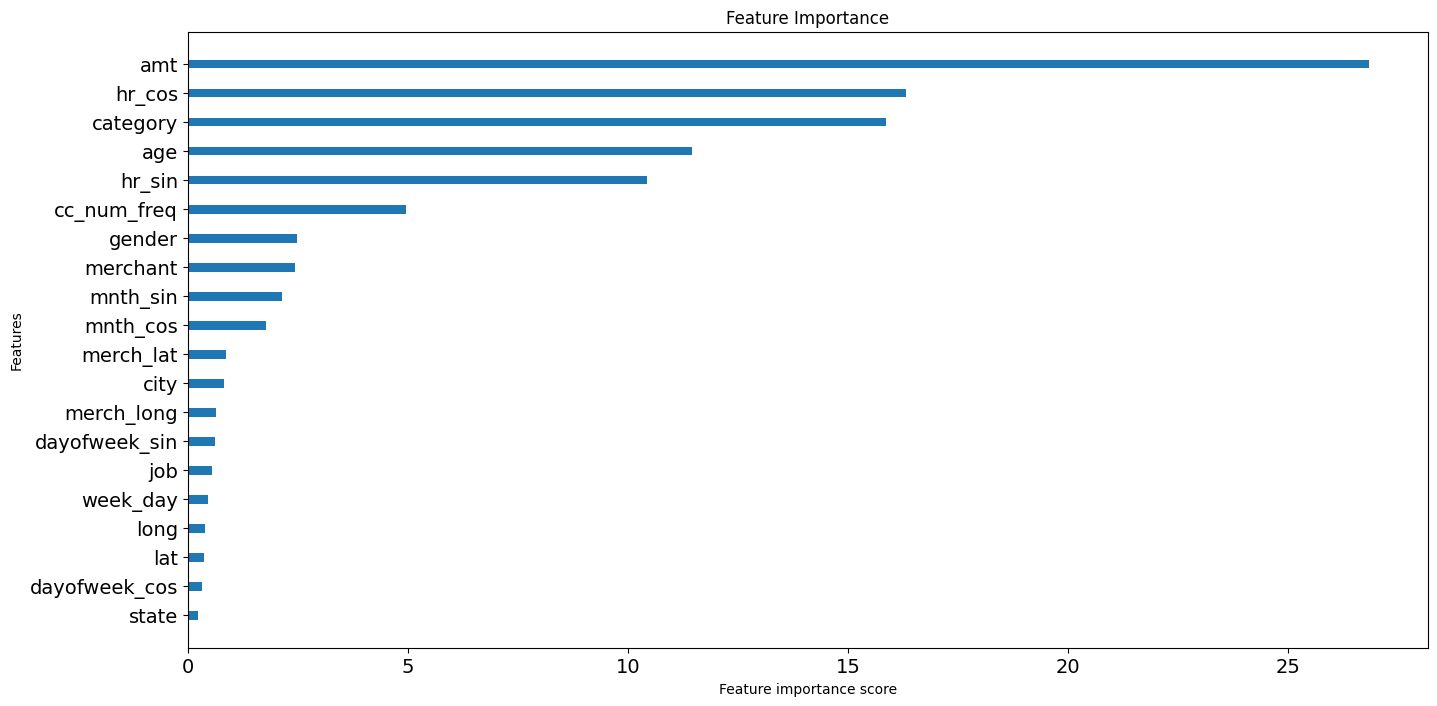

In [34]:
feature_scores = pd.Series(cb.feature_importances_, index=X_train.columns).sort_values(ascending=True)

f, ax = plt.subplots(figsize=(16,8))
ax.barh(width=feature_scores, y=feature_scores.index, data=df, height=0.3)
ax.set_title("Feature Importance")
ax.set_yticklabels(feature_scores.index)
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

From the bar plot above, we can see that the top few important features in the CatBoost Classifier are the transaction amount, transaction category, hour of transaction and age. All the top few features agree with that of the XGBoost classifier except for the hour of transaction. We will now take a look at the hour of transaction and its relationship to whether a transaction is legitimate or fraudulent.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

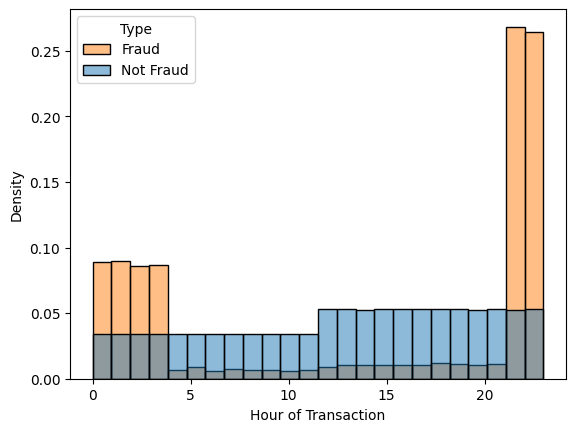

In [35]:
ax = sns.histplot(x = 'hr', data = df_copy,
                 hue = 'is_fraud', stat='density',
                 common_norm = False, bins = 24)

ax.set_ylabel('Density')
ax.set_xlabel('Hour of Transaction')
ax.legend(title='Type', labels=['Fraud', 'Not Fraud'])

We can see that fraudulent transactions tend to happen late at night when most people are asleep. This explains why 'hr_cos' ranks high in the feature importance, since the 'hr_cos' value is cyclical so even though 0 and 23 are not considered close when we consider numbers ranging from 0 to 23, they are close together when we map them as cyclical variables. E.g. 1 and 23 have the same 'hr_cos' value. Hence, the amount of fraudulent cases happen to be the most when 'hr_cos' is positive and near magnitude of 1 (which are the values of the hours when fraudulent cases are higher), as seen below.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

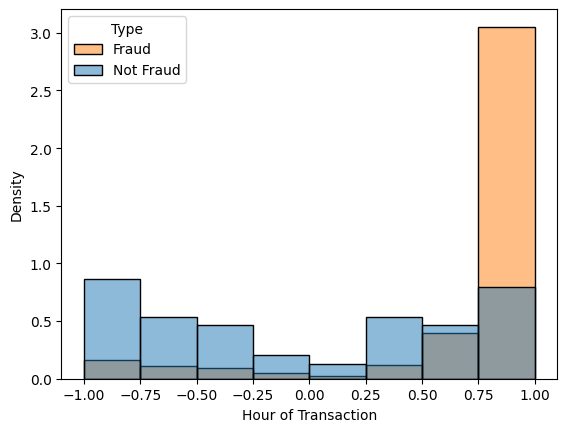

In [36]:
ax = sns.histplot(x = 'hr_cos', data = df_copy,
                 hue = 'is_fraud', stat='density',
                 common_norm = False, bins = 8)

ax.set_ylabel('Density')
ax.set_xlabel('Hour of Transaction')
ax.legend(title='Type', labels=['Fraud', 'Not Fraud'])

## **RandomForestClassifier**

We will need to encode the categorical variables in our dataset for the RandomForestClassifier.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 1296674
Data columns (total 21 columns):
 #   Column         Dtype   
---  ------         -----   
 0   merchant       category
 1   category       category
 2   amt            float64 
 3   gender         category
 4   city           category
 5   state          category
 6   lat            float64 
 7   long           float64 
 8   job            category
 9   merch_lat      float64 
 10  merch_long     float64 
 11  is_fraud       int64   
 12  age            int64   
 13  cc_num_freq    int64   
 14  week_day       int32   
 15  hr_sin         float64 
 16  hr_cos         float64 
 17  mnth_sin       float64 
 18  mnth_cos       float64 
 19  dayofweek_sin  float64 
 20  dayofweek_cos  float64 
dtypes: category(6), float64(11), int32(1), int64(3)
memory usage: 235.0 MB


We use Weight of Evidence (WOE) to encode categorical variables of high cardinality.

In [38]:
import category_encoders as ce

def apply_woe(X_train, y_train, X_test, columns):
    woe = ce.WOEEncoder()

    X_train_rf = X_train.copy()
    X_test_rf = X_test.copy()
    
    for col in columns:
        X = X_train_rf[col]
        y = y_train
        test_col = X_test_rf[col]

        new_col_name = f"{col}_WOE"
        X_train_rf[new_col_name] = woe.fit_transform(X, y)
        X_test_rf[new_col_name] = woe.transform(test_col)
    X_train_rf.drop(columns=columns, inplace=True)
    X_test_rf.drop(columns=columns, inplace=True)

    return X_train_rf, X_test_rf
    
columns_to_encode = ["merchant", "category", 
                     "city", "state", "job"]

output = apply_woe(X_train, y_train, X_test, columns_to_encode)

X_train_rf = output[0]
X_test_rf = output[1]
X_train_rf.head()

,amt,gender,lat,long,merch_lat,merch_long,age,cc_num_freq,week_day,hr_sin,hr_cos,mnth_sin,mnth_cos,dayofweek_sin,dayofweek_cos,merchant_WOE,category_WOE,city_WOE,state_WOE,job_WOE
1029737,33.62,M,32.7004,-97.6039,32.632183,-97.055722,41,1469,0,-1.000000e+00,-1.836970e-16,0.866025,5.000000e-01,0.000000,1.000000,-1.455616,-1.271305,0.412343,-0.199949,0.816496
1148989,4.75,M,28.1762,-81.9591,27.975035,-81.176870,76,1466,4,8.660254e-01,5.000000e-01,1.000000,6.123234e-17,-0.433884,-0.900969,0.163657,0.160317,-0.349555,0.080261,0.297689
1041882,29.34,M,33.7163,-116.3381,33.090599,-115.631010,70,2195,6,1.224647e-16,-1.000000e+00,0.866025,5.000000e-01,-0.781831,0.623490,-1.458449,-1.271305,0.246562,-0.034108,0.246562
940189,78.72,M,44.6873,-104.4414,44.123976,-104.772649,52,1466,4,-5.000000e-01,-8.660254e-01,0.000000,1.000000e+00,-0.433884,-0.900969,-0.175553,-0.858945,-0.046775,-0.254829,0.462315
187788,77.86,M,44.1554,-72.4847,43.335855,-73.039493,32,2927,6,-7.071068e-01,-7.071068e-01,1.000000,6.123234e-17,-0.781831,0.623490,-0.772551,-1.271305,0.040113,-0.090237,-0.416345


We check for any categories that may have been missed out from the WOE encoding.

In [39]:
X_test_rf.isnull().sum()

amt              0
gender           0
lat              0
long             0
merch_lat        0
merch_long       0
age              0
cc_num_freq      0
week_day         0
hr_sin           0
hr_cos           0
mnth_sin         0
mnth_cos         0
dayofweek_sin    0
dayofweek_cos    0
merchant_WOE     0
category_WOE     0
city_WOE         0
state_WOE        0
job_WOE          0
dtype: int64

We perform One Hot Encoding for the 'gender' column since it only has two variables.

In [40]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False).set_output(transform = 'pandas')
ohe = enc.fit_transform(X_train_rf[['gender']])

X_train_rf = pd.concat([X_train_rf, ohe], axis=1).drop(columns=['gender'])

In [41]:
ohe = enc.fit_transform(X_test_rf[['gender']])
X_test_rf = pd.concat([X_test_rf, ohe], axis=1).drop(columns=['gender'])

In [42]:
from sklearn.ensemble import RandomForestClassifier

### **Hyperparameters Tuning with Optuna**

In [43]:
def objective(trial):
    space={'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10), 
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
           # trial.suggest_float('max_features', 0.1, 0.999)
    }
    rf = RandomForestClassifier(**space, random_state = 8, n_jobs = -1)
    
    rf.fit(X_train_rf, y_train)
    
    pred = rf.predict(X_test_rf)
    score = accuracy_score(y_test, pred)
    return score

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=8))
study.optimize(objective, n_trials=20)

[I 2025-10-29 02:36:14,870] A new study created in memory with name: no-name-175c1661-db5a-4099-86aa-8d9dcb769706
[I 2025-10-29 02:57:26,925] Trial 0 finished with value: 0.9967987418101595 and parameters: {'max_depth': 9, 'n_estimators': 972, 'min_samples_split': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9967987418101595.
[I 2025-10-29 03:01:31,665] Trial 1 finished with value: 0.9951684214504093 and parameters: {'max_depth': 3, 'n_estimators': 487, 'min_samples_split': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9967987418101595.
[I 2025-10-29 03:12:09,032] Trial 2 finished with value: 0.996289491631562 and parameters: {'max_depth': 7, 'n_estimators': 589, 'min_samples_split': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9967987418101595.
[I 2025-10-29 03:17:24,903] Trial 3 finished with value: 0.9960177715716036 and parameters: {'max_depth': 6, 'n_estimators': 360, 'min_samples_split': 10, 'max_features': 'sqrt'}. Best is trial 0 with value

In [44]:
trial = study.best_trial
print('Accuracy: {}'.format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Accuracy: 0.9972792004592249
Best hyperparameters: {'max_depth': 10, 'n_estimators': 780, 'min_samples_split': 7, 'max_features': 'log2'}


In [45]:
best_hyperparams_rf = trial.params

### **Train the Random Forest Classifier**

In [46]:
import time

rf = RandomForestClassifier(**best_hyperparams_rf, random_state = 8, n_jobs = -1)

start_train_time = time.perf_counter()
rf.fit(X_train_rf, y_train)

end_train_time = time.perf_counter()
train_duration = end_train_time - start_train_time
print(f"Model training time: {train_duration:.4f} seconds")

Model training time: 1372.6251 seconds


In [47]:
start_time_predict = time.perf_counter()
y_pred = rf.predict(X_test_rf)
end_time_predict = time.perf_counter()
print(f"Model prediction time: {end_time_predict - start_time_predict:.4f} seconds")

Model prediction time: 18.6157 seconds


### **Evaluation of Model**

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9973
Precision: 0.9664
Recall: 0.5010
F1 Score: 0.6599


### **Feature Importance**

/tmp/ipykernel_36/3344756591.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(feature_scores.index)


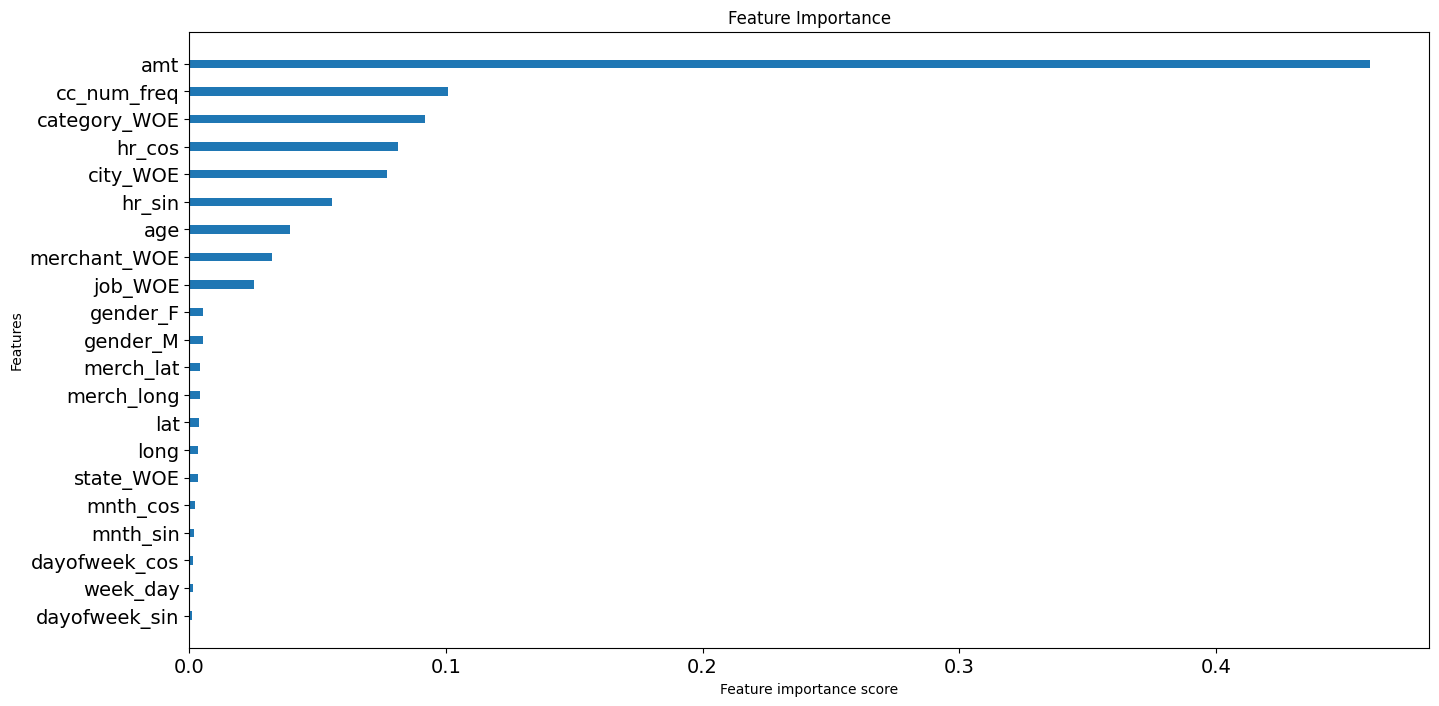

In [49]:
feature_scores = pd.Series(rf.feature_importances_, index=X_train_rf.columns).sort_values(ascending=True)

f, ax = plt.subplots(figsize=(16,8))
ax.barh(width=feature_scores, y=feature_scores.index, data=df, height=0.3)
ax.set_title("Feature Importance")
ax.set_yticklabels(feature_scores.index)
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

From the bar plot above, we can see that the top few important features in the Random Forest Classifier are the transaction amount, transaction category, hour of transaction and credit card usage frequency. All the top few features agree with that of the XGBoost classifier and CatBoost classifier.

## **Model Comparison**

| Metric | XGBoost | CatBoost | RandomForest |
| :------- | :------: | -------: | -------: |
| Accuracy  | 0.9989  | 0.9990 | 0.9973  | 
| Precision  | 0.9500  | 0.9706 | 0.9664  |
| Recall  | 0.8443  | 0.8453 | 0.5010  |
| F1 Score  | 0.8940  | 0.9036 | 0.6599  |
| Training Time (s) | 60.2728  | 306.4453 | 1372.6251  |
| Prediction Time (s)  | 4.3794  | 2.2895 | 18.6157  |

We compare the ROC curve for all models below.

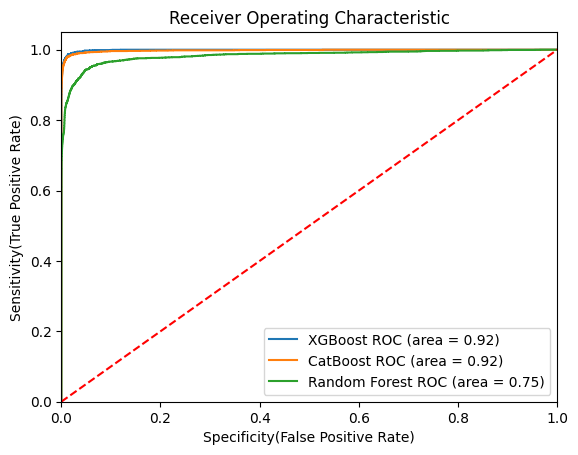

In [50]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
auc = metrics.roc_auc_score(y_test,xgb_clf.predict(X_test))

fpr1, tpr1, thresholds1 = metrics.roc_curve(y_test, cb.predict_proba(X_test)[:,1])
auc1 = metrics.roc_auc_score(y_test,cb.predict(X_test))

fpr2, tpr2, thresholds2 = metrics.roc_curve(y_test, rf.predict_proba(X_test_rf)[:,1])
auc2 = metrics.roc_auc_score(y_test,rf.predict(X_test_rf))

plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % ('XGBoost', auc))
plt.plot(fpr1, tpr1, label='%s ROC (area = %0.2f)' % ('CatBoost', auc1))
plt.plot(fpr2, tpr2, label='%s ROC (area = %0.2f)' % ('Random Forest', auc2))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Overall, we can see the CatBoost has the best performance out of all models in all metric such as recall and prediction time. The performance of XGBoost is slightly worse, however XGBoost is observed to have a much faster training time. The ROC curves of CatBoost and XGBoost seems to be nearly identical, with the same area, indicating comparable predictive performance. Random Forest has the worst performance across all metric. 

The recall metric is especially important as the cost of missing a fraudulent transaction (a false negative) is significantly higher than the cost of incorrectly flagging a legitimate transaction (a false positive). A high recall ensures that a fraud detection system captures as many actual fraud cases as possible, minimizing financial losses and protecting customer trust. 

A disadvantage of Random Forest as compared to the other models is that it does not accept categorical variables as input. Therefore the categorical variables need to be encoded before they can be used to train the model. We used Weight of Evidence encoding for variables of high cardinality in our data, which quantifies the discriminatory power of a predictor category, with positive values indicating a tendency for the positive outcome and negative values a tendency for the negative outcome. A disadvantage of this method of encoding is that it may lead to overfitting and there may be issues if the new dataset that we are using the model to make prediction contains new categories not found in the training dataset. 


## **Conclusion**

Overall, we can see that both CatBoost and XGBoost have demonstrated superior performance in fraud detection and can be considered to be deployed in banks to aid them in identifying fraudulent activities.

While the use of prediction models are useful in reducing the number of frauds, other prevention methods are necessary as well.

More campaign efforts can be made to educate elderly on credit card fraud prevention techniques. 
The bank can also send emails and/or text messages to customers every time their account experiences:

- Irregular account activity.
- A card-not-present transaction made online or by phone.
- A cash advance.
- Foreign transactions.
- A purchase over a set price, such as $100. This amount can be decided by the customers.

The bank can also encourage customers to: 

- Regularly monitor their account for unusual activities
- Sign up for fraud alerts.
- Ensure their account information is always accurate and up-to-date.
- Bookmark the sites you visit most, or type in the URL, instead of clicking on links.
- Keep personal information secure.
- Avoid sharing personal information like credit card numbers over the phone.